In [9]:


subsets = {

1:  {"target":"End_Longitude",
     "support":["Species","Region","Habitat","Weather_Condition","End_Latitude","Migration_Reason"]},

2:  {"target":"Migration_Success",
     "support":["Migration_Reason","Species","Weather_Condition","Habitat"]},

3:  {"target":"Migration_Success",
     "support":["Interrupted_Reason","Weather_Condition","Habitat","Species","Migration_Interrupted"]},

4:  {"target":"Flight_Distance_km",
     "support":["Start_Latitude","Start_Longitude","End_Latitude","End_Longitude","Migration_Success"]},

5:  {"target":"End_Longitude",
     "support":["Species","Start_Latitude","Start_Longitude","End_Latitude"]},

6:  {"target":"End_Longitude",
     "support":["Species","Start_Latitude","Start_Longitude","End_Latitude","Region"]},

7:  {"target":"Migration_Success",
     "support":["Start_Latitude","Start_Longitude","End_Latitude","End_Longitude"]},

8:  {"target":"Origin",
     "support":["End_Latitude","End_Longitude","Interrupted_Reason","Migration_Success"]},

9:  {"target":"Origin",
     "support":["Migration_Success","Region","Habitat","Start_Latitude","End_Latitude"]},

10: {"target":"Origin",
     "support":["Observation_Counts","Species","End_Latitude","End_Longitude"]},

11: {"target":"Migration_Success",
     "support":["Species","Weather_Condition"]},

12: {"target":"Observation_Counts",
     "support":["Weather_Condition","Migration_Reason"]},

13: {"target":"Flight_Distance_km",
     "support":["Species","Start_Latitude","Start_Longitude"]},

14: {"target":"Migration_Success",
     "support":["Interrupted_Reason","Weather_Condition"]},

15: {"target":"Observation_Counts",
     "support":["Flight_Distance_km","Species"]},

16: {"target":"Migration_Success",
     "support":["Species","Habitat","Weather_Condition"]},

17: {"target":"Migration_Success",
     "support":["Weather_Condition","Habitat","Species"]},

18: {"target":"Migration_Success",
     "support":["Flight_Distance_km","Species","Habitat"]},

19: {"target":"Migration_Success",
     "support":["Weather_Condition","Habitat","Migration_Interrupted"]},

20: {"target":"Migration_Success",
     "support":["Species","Interrupted_Reason","Weather_Condition","Flight_Distance_km"]}
}


Optimal Decision Tree: C4.5

Performance Matrix

  Performance Measure       KNN  Naive Bayes      C4.5
0            Accuracy  0.255000     0.239000  0.249000
1           Precision  0.254252     0.238246  0.257963
2              Recall  0.255000     0.239000  0.249000
3            F1 Score  0.250484     0.237103  0.228008
4         Specificity  0.751536     0.746254  0.749816


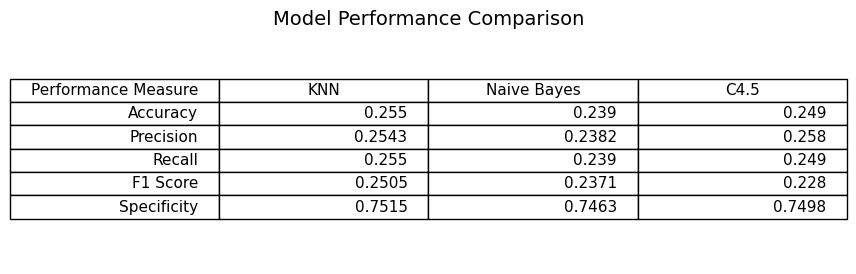


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): KNN


In [ ]:
# -----------------------------
# SELECT SUBSET NUMBER
# -----------------------------
question_no = 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"D:\Mini project\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.486000     0.503500  0.488500
1           Precision  0.488803     0.505611  0.494152
2              Recall  0.486000     0.503500  0.488500
3            F1 Score  0.486416     0.503991  0.487103
4         Specificity  0.499466     0.505870  0.552828


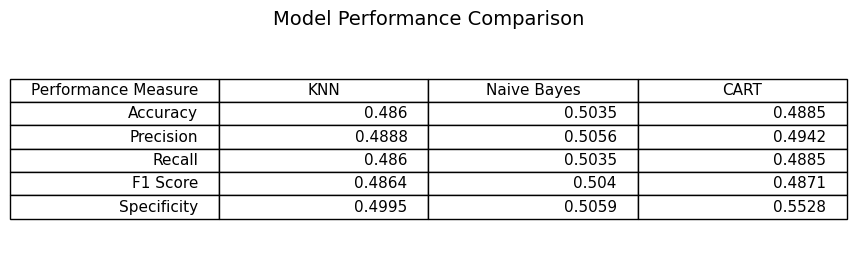


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): Naive Bayes


In [12]:
question_no = 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: ID3

Performance Matrix

  Performance Measure       KNN  Naive Bayes       ID3
0            Accuracy  0.489401     0.511845  0.498130
1           Precision  0.489547     0.512184  0.497622
2              Recall  0.489401     0.511845  0.498130
3            F1 Score  0.489089     0.511120  0.495213
4         Specificity  0.464684     0.473358  0.573730


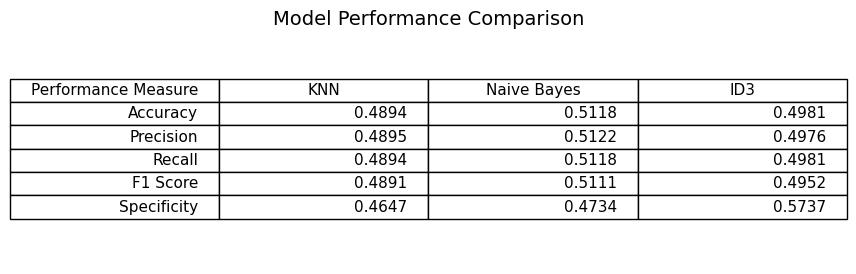


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): ID3


In [ ]:
question_no = 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)
best_tree_name="CART"
if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: ID3

Performance Matrix

  Performance Measure       KNN  Naive Bayes       ID3
0            Accuracy  0.242000     0.255500  0.253500
1           Precision  0.240514     0.244850  0.253608
2              Recall  0.242000     0.255500  0.253500
3            F1 Score  0.236222     0.213063  0.253486
4         Specificity  0.747087     0.751175  0.751123


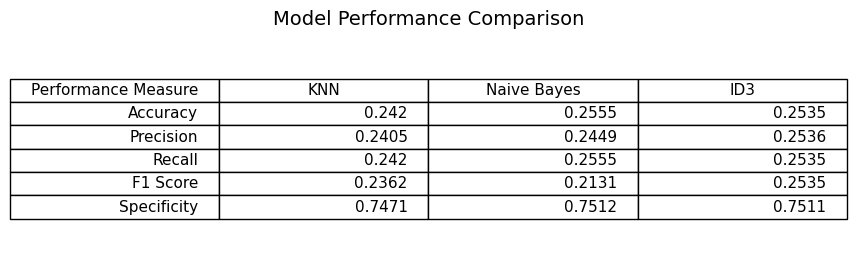


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): ID3


In [14]:
question_no +=1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.258000     0.249500  0.256500
1           Precision  0.258431     0.244090  0.256920
2              Recall  0.258000     0.249500  0.256500
3            F1 Score  0.253618     0.236619  0.256540
4         Specificity  0.752455     0.749882  0.752184


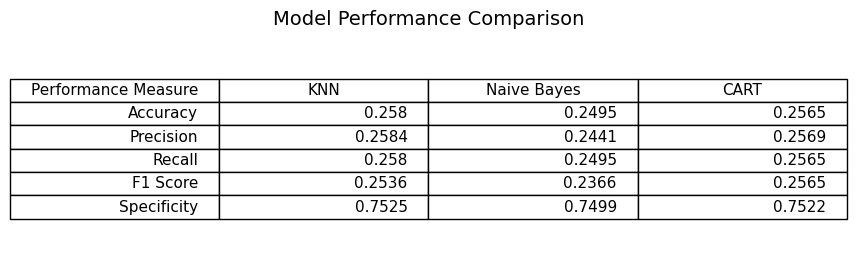


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): KNN


In [17]:
question_no =5

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)
best_tree_name="CART"
if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.494500     0.510500  0.495000
1           Precision  0.496360     0.503513  0.498571
2              Recall  0.494500     0.510500  0.495000
3            F1 Score  0.495000     0.500528  0.495173
4         Specificity  0.491996     0.357524  0.521878


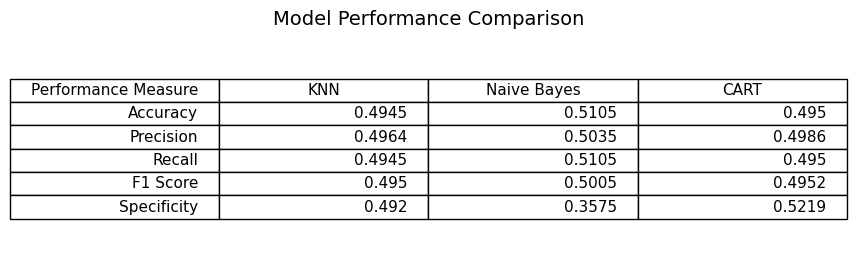


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): CART


In [ ]:
question_no =6

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)
best_tree_name="CART"
if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: ID3

Performance Matrix

  Performance Measure       KNN  Naive Bayes       ID3
0            Accuracy  0.240648     0.254364  0.263092
1           Precision  0.240391     0.262727  0.263038
2              Recall  0.240648     0.254364  0.263092
3            F1 Score  0.235903     0.234466  0.262712
4         Specificity  0.747460     0.751041  0.754392


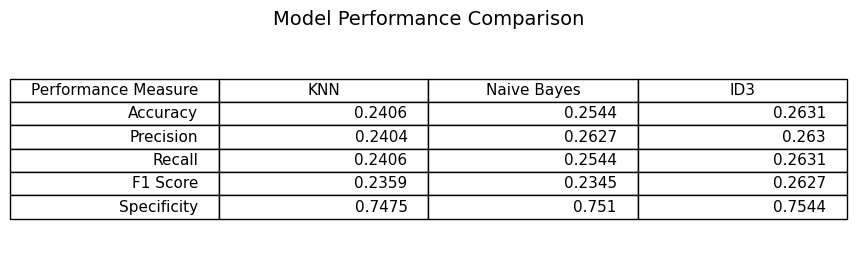


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): ID3


In [ ]:
question_no =7

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: C4.5

Performance Matrix

  Performance Measure       KNN  Naive Bayes      C4.5
0            Accuracy  0.251000     0.257000  0.252500
1           Precision  0.251506     0.256018  0.177062
2              Recall  0.251000     0.257000  0.252500
3            F1 Score  0.246413     0.252434  0.130868
4         Specificity  0.750029     0.752235  0.751450


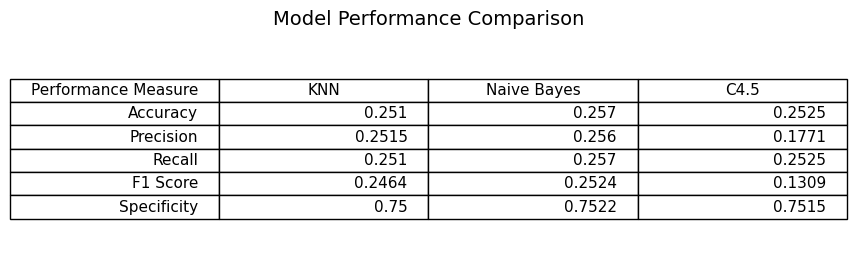


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): Naive Bayes


In [ ]:
question_no =8

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)
best_tree_name="C4.5"
if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: C4.5

Performance Matrix

  Performance Measure       KNN  Naive Bayes      C4.5
0            Accuracy  0.501000     0.486500  0.497000
1           Precision  0.501616     0.487201  0.573112
2              Recall  0.501000     0.486500  0.497000
3            F1 Score  0.501122     0.485837  0.370186
4         Specificity  0.833696     0.828894  0.833838


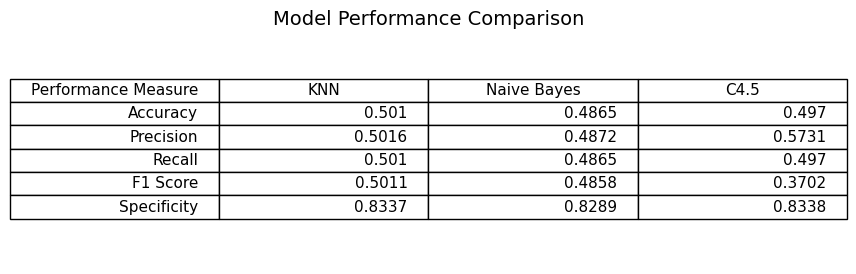


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): KNN


In [24]:
question_no=9

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)
best_tree_name="C4.5"
if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.251000     0.257000  0.255000
1           Precision  0.251506     0.256018  0.255227
2              Recall  0.251000     0.257000  0.255000
3            F1 Score  0.246413     0.252434  0.255014
4         Specificity  0.750029     0.752235  0.751650


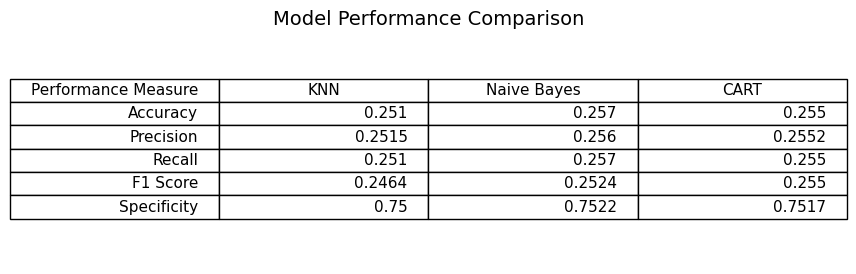


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): Naive Bayes


In [25]:
question_no =10

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: C4.5

Performance Matrix

  Performance Measure       KNN  Naive Bayes      C4.5
0            Accuracy  0.509500     0.495500  0.501000
1           Precision  0.513122     0.500296  0.510019
2              Recall  0.509500     0.495500  0.501000
3            F1 Score  0.509680     0.494979  0.496019
4         Specificity  0.536820     0.543223  0.612593


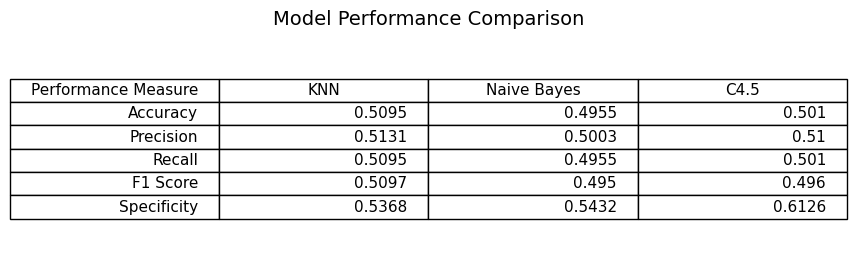


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): C4.5


In [26]:
question_no =11

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.249000     0.242500  0.253500
1           Precision  0.251360     0.243817  0.242323
2              Recall  0.249000     0.242500  0.253500
3            F1 Score  0.244336     0.224522  0.227891
4         Specificity  0.749564     0.748758  0.750352


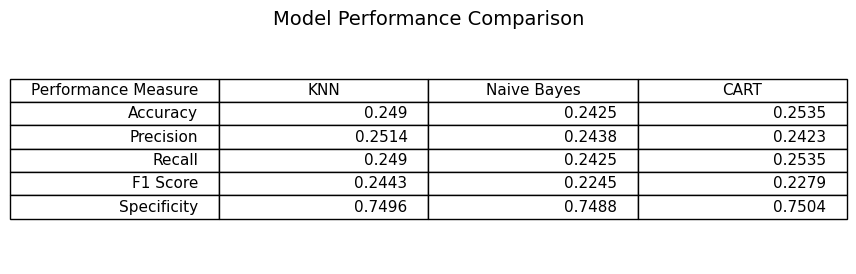


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): KNN


In [27]:
question_no =12

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.246000     0.259500  0.249500
1           Precision  0.248200     0.255775  0.249935
2              Recall  0.246000     0.259500  0.249500
3            F1 Score  0.242917     0.252974  0.249359
4         Specificity  0.748476     0.752960  0.749893


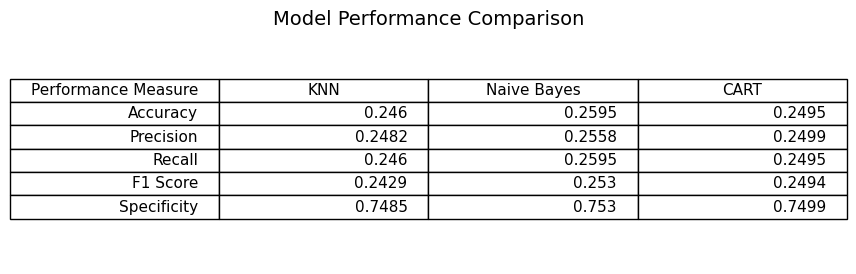


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): Naive Bayes


In [28]:
question_no =13

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.511222     0.488155  0.503741
1           Precision  0.511696     0.488174  0.504601
2              Recall  0.511222     0.488155  0.503741
3            F1 Score  0.509915     0.488160  0.498441
4         Specificity  0.459727     0.488228  0.401487


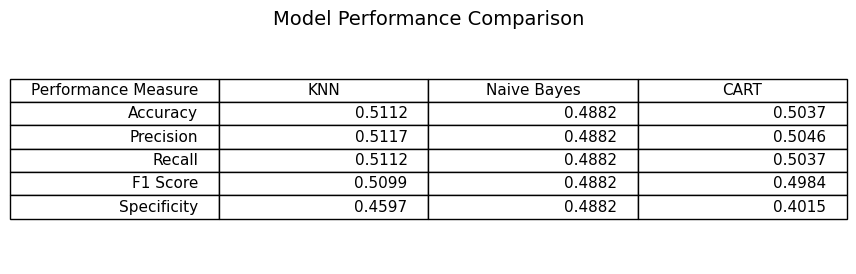


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): KNN


In [29]:
question_no =14

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: ID3

Performance Matrix

  Performance Measure       KNN  Naive Bayes       ID3
0            Accuracy  0.237500     0.240000  0.242500
1           Precision  0.237466     0.238827  0.242441
2              Recall  0.237500     0.240000  0.242500
3            F1 Score  0.231364     0.234231  0.242218
4         Specificity  0.745748     0.747151  0.747529


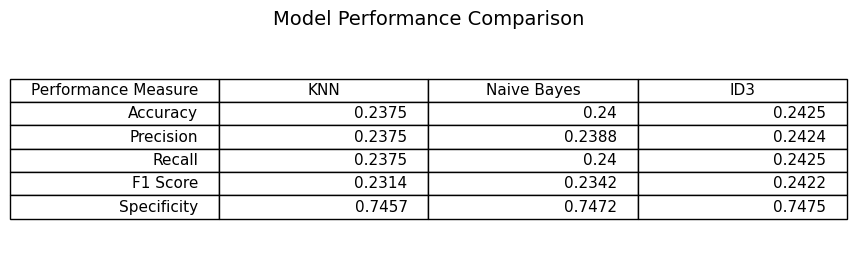


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): ID3


In [30]:
question_no =15

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: C4.5

Performance Matrix

  Performance Measure       KNN  Naive Bayes      C4.5
0            Accuracy  0.507500     0.497000  0.466500
1           Precision  0.512120     0.500583  0.477497
2              Recall  0.507500     0.497000  0.466500
3            F1 Score  0.507201     0.497172  0.433213
4         Specificity  0.550694     0.524013  0.726788


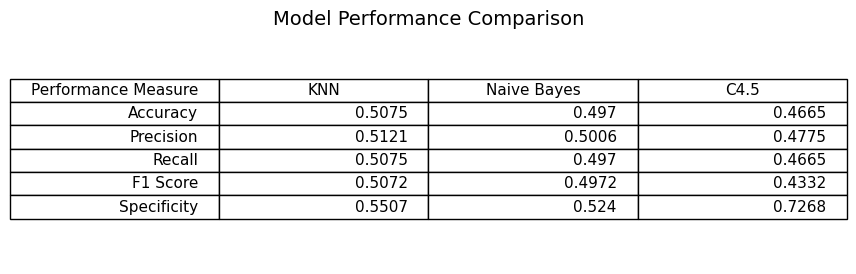


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): KNN


In [31]:
question_no =16

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: C4.5

Performance Matrix

  Performance Measure       KNN  Naive Bayes      C4.5
0            Accuracy  0.507500     0.497000  0.466500
1           Precision  0.512120     0.500583  0.477497
2              Recall  0.507500     0.497000  0.466500
3            F1 Score  0.507201     0.497172  0.433213
4         Specificity  0.550694     0.524013  0.726788


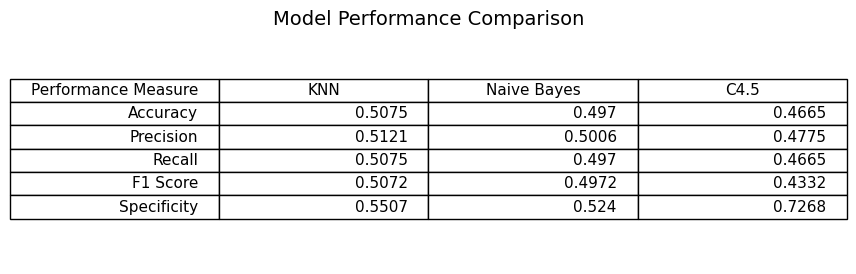


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): KNN


In [32]:
question_no =17

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.501500     0.488000  0.517000
1           Precision  0.503928     0.492187  0.518628
2              Recall  0.501500     0.488000  0.517000
3            F1 Score  0.501970     0.487826  0.517465
4         Specificity  0.509072     0.526147  0.512273


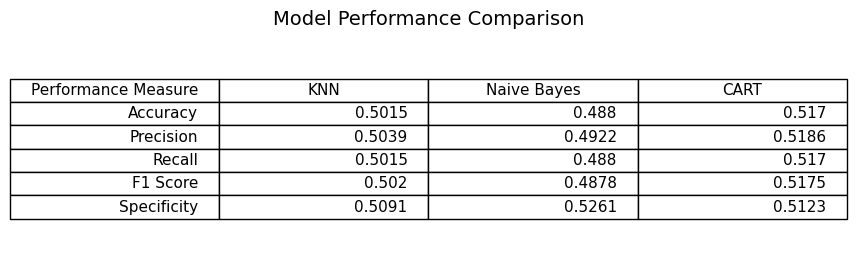


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): CART


In [33]:
question_no =18

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.512000     0.519000  0.506500
1           Precision  0.518153     0.506703  0.510503
2              Recall  0.512000     0.519000  0.506500
3            F1 Score  0.510697     0.488934  0.506515
4         Specificity  0.577375     0.261473  0.540021


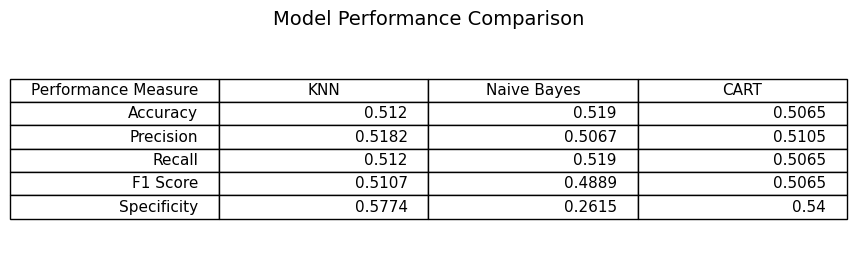


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): KNN


In [34]:
question_no =19

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)


Optimal Decision Tree: CART

Performance Matrix

  Performance Measure       KNN  Naive Bayes      CART
0            Accuracy  0.521197     0.500623  0.511222
1           Precision  0.521452     0.500964  0.511279
2              Recall  0.521197     0.500623  0.511222
3            F1 Score  0.520857     0.499383  0.511211
4         Specificity  0.494424     0.451053  0.505576


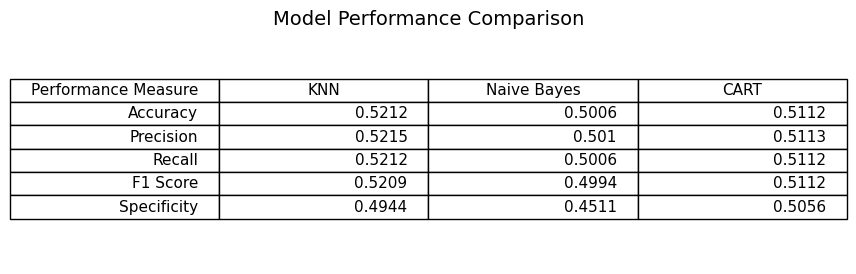


Final Optimal Algorithm (among KNN, Naive Bayes, Decision Tree): KNN


In [35]:
question_no =20

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# -----------------------------
# LOAD DATASET
# -----------------------------
df = pd.read_excel(r"C:\Users\gsbag\Desktop\MSEC\DA\Bird_Migration_Data_with _names_and_origin.xlsx")

target = subsets[question_no]["target"]
support = subsets[question_no]["support"]

subset_df = df[support + [target]].dropna().copy()


# -----------------------------
# TARGET PREPROCESSING
# -----------------------------

# CASE 1 : Origin coordinates
if target.lower() == "origin":

    subset_df[['lat_temp','lon_temp']] = subset_df[target].str.split(',', expand=True).astype(float)

    lat_med = subset_df['lat_temp'].median()
    lon_med = subset_df['lon_temp'].median()

    def assign_quadrant(row):

        if row['lat_temp'] >= lat_med and row['lon_temp'] >= lon_med:
            return "North-East"

        elif row['lat_temp'] >= lat_med and row['lon_temp'] < lon_med:
            return "North-West"

        elif row['lat_temp'] < lat_med and row['lon_temp'] >= lon_med:
            return "South-East"

        else:
            return "South-West"

    subset_df['target_binned'] = subset_df.apply(assign_quadrant, axis=1)


# CASE 2 : Latitude / Longitude
elif target.lower() in ["latitude","longitude"]:

    labels = ["Far West","West","East","Far East"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 3 : Other numeric values
elif pd.api.types.is_numeric_dtype(subset_df[target]):

    labels = ["Low Value","Mid-Low","Mid-High","High Value"]

    subset_df['target_binned'] = pd.qcut(
        subset_df[target],
        q=4,
        labels=labels
    )


# CASE 4 : Boolean / categorical values
else:

    subset_df['target_binned'] = subset_df[target].astype("category")


# -----------------------------
# FEATURE PROCESSING
# -----------------------------
X = pd.get_dummies(subset_df[support])
y = subset_df['target_binned'].astype("category").cat.codes


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# -----------------------------
# DECISION TREE MODELS
# -----------------------------
cart_tree = DecisionTreeClassifier(criterion="gini")
id3_tree = DecisionTreeClassifier(criterion="entropy")
c45_tree = DecisionTreeClassifier(criterion="entropy", max_depth=3)

cart_tree.fit(X_train, y_train)
id3_tree.fit(X_train, y_train)
c45_tree.fit(X_train, y_train)


# -----------------------------
# KNN MODEL
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


# -----------------------------
# NAIVE BAYES MODEL
# -----------------------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


# -----------------------------
# SPECIFICITY FUNCTION
# -----------------------------
def specificity_score(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2,2):

        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) != 0 else 0

    else:

        spec_list = []

        for i in range(len(cm)):

            tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            fp = cm[:,i].sum() - cm[i,i]

            spec = tn / (tn + fp) if (tn + fp) != 0 else 0
            spec_list.append(spec)

        return np.mean(spec_list)


# -----------------------------
# EVALUATION FUNCTION
# -----------------------------
def evaluate(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    spec = specificity_score(y_test, y_pred)

    return [acc, prec, rec, f1, spec]


# -----------------------------
# EVALUATE DECISION TREES
# -----------------------------
cart_metrics = evaluate(cart_tree)
id3_metrics = evaluate(id3_tree)
c45_metrics = evaluate(c45_tree)


# FIND BEST DECISION TREE
tree_scores = {
    "CART": np.mean(cart_metrics),
    "ID3": np.mean(id3_metrics),
    "C4.5": np.mean(c45_metrics)
}

best_tree_name = max(tree_scores, key=tree_scores.get)

if best_tree_name == "CART":
    best_tree_metrics = cart_metrics

elif best_tree_name == "ID3":
    best_tree_metrics = id3_metrics

else:
    best_tree_metrics = c45_metrics


# -----------------------------
# EVALUATE KNN & NAIVE BAYES
# -----------------------------
knn_metrics = evaluate(knn_model)
nb_metrics = evaluate(nb_model)


# -----------------------------
# FIND FINAL BEST MODEL
# -----------------------------
model_scores = {
    "KNN": np.mean(knn_metrics),
    "Naive Bayes": np.mean(nb_metrics),
    best_tree_name: np.mean(best_tree_metrics)
}

final_best_model = max(model_scores, key=model_scores.get)


# -----------------------------
# CREATE PERFORMANCE MATRIX
# -----------------------------
metrics_names = ["Accuracy","Precision","Recall","F1 Score","Specificity"]

performance_matrix = pd.DataFrame({
    "Performance Measure": metrics_names,
    "KNN": knn_metrics,
    "Naive Bayes": nb_metrics,
    best_tree_name: best_tree_metrics
})

print("\nOptimal Decision Tree:", best_tree_name)

print("\nPerformance Matrix\n")
print(performance_matrix)


# -----------------------------
# EXPORT TABLE FOR WORD
# -----------------------------
performance_matrix.to_csv("Performance_Matrix_Table.csv", index=False)


# -----------------------------
# CREATE WORD-LIKE TABLE IMAGE
# -----------------------------
fig, ax = plt.subplots(figsize=(9,3))
ax.axis("off")

table = ax.table(
    cellText=performance_matrix.round(4).values,
    colLabels=performance_matrix.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,1.4)

plt.title("Model Performance Comparison", fontsize=14)

plt.savefig("Performance_Matrix_Table.png", dpi=300, bbox_inches="tight")

plt.show()


print("\nFinal Optimal Algorithm (among KNN, Naive Bayes, Decision Tree):", final_best_model)